<a href="https://colab.research.google.com/github/RajeshRanaGiet/DMPM-Lab/blob/main/Experiment%207/Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cluster Labels :
[0 0 0 1 1 1]

Cluster Centers : 
[[ 3.          3.33333333]
 [11.         11.33333333]]


/tmp/ipykernel_2662/3251754595.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


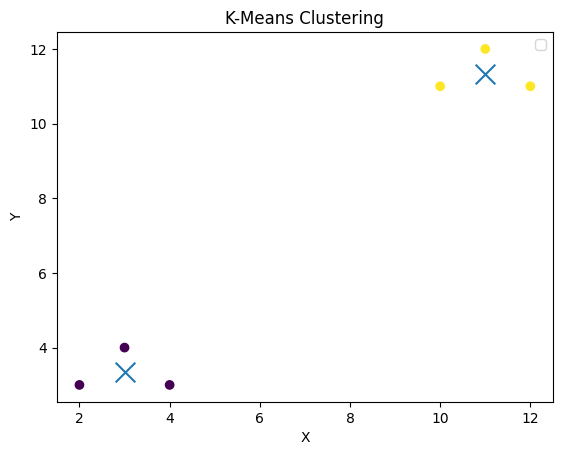

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = np.array([[2,3],
              [3,4],
              [4,3],
              [10,11],
              [11,12],
              [12,11]])
#Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

# Display cluster information
print("Cluster Labels :")
print(labels)

print("\nCluster Centers : ")
print(kmeans.cluster_centers_)

# Plot clusters
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker='x',
    s=200
)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means Clustering")
plt.legend()
plt.show()


Cluster Labels :
[0 0 0 1 1 1]

Medoid points :
[3 4]
[11 12]


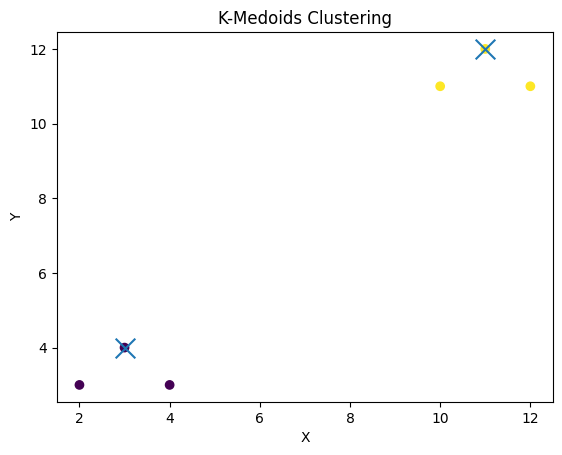

In [11]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[2,3],
              [3,4],
              [4,3],
              [10,11],
              [11,12],
              [12,11]])
k = 2
medoid_indices = [0,3]
while True:
  distances = np.zeros((len(X), k))
  for i in range(len(X)):
    for j in range(k):
      distances[i,j] = np.linalg.norm(X[i] - X[medoid_indices[j]])
  labels = np.argmin(distances, axis=1)
  new_medoid_indices = []
  for cluster in range(k):
    cluster_indices = np.where(labels == cluster)[0]
    if len(cluster_indices) == 0:
      new_medoid_indices.append(medoid_indices[cluster])
      continue
    total_distance = []
    for i in cluster_indices:
      total = 0
      for j in cluster_indices:
        total += np.linalg.norm(X[i] - X[j])
      total_distance.append(total)
    new_medoid = cluster_indices[np.argmin(total_distance)]
    new_medoid_indices.append(new_medoid)
  if new_medoid_indices == medoid_indices:
    break
  medoid_indices = new_medoid_indices
print("Cluster Labels :")
print(labels)
print("\nMedoid points :")
for index in medoid_indices:
  print(X[index])
plt.scatter(X[:,0], X[:,1], c=labels)
medoids = X[medoid_indices]
plt.scatter(medoids[:,0], medoids[:,1], marker='x', s=200)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Medoids Clustering")
plt.show()


